# 데이터 출처

- 중소벤처기업부, Korea AI Manufacturing Platform(KAMP), 소성가공 자원최적화 AI 데이터셋,
- KAIST(울산과학기술원, ㈜리쉐니에), 2022.12.23., www.kamp-ai.kr

# 1. Data Loading 및 기본 조회

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from datetime import datetime

# 1. 그래프 크기와 폰트 설정 (최신 방식)
plt.figure(figsize=(10, 8)) # 화면 크기 확대 (가로 10, 세로 8)
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

<Figure size 1000x800 with 0 Axes>

In [4]:
org_df = pd.read_csv('./data/okm_augumented_2021.csv')

org_df.head(20)

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5
5,20210101,5,89,83,99,98,92,0,-5.5,2.1,66,0.0,109.8,5,1,1,0.0,1.5
6,20210101,6,102,111,110,103,107,0,-5.6,1.5,67,0.0,109.8,5,1,1,0.0,1.5
7,20210101,7,92,75,48,29,61,0,-6.8,0.6,73,0.0,109.8,5,1,1,0.0,1.5
8,20210101,8,27,25,22,22,24,0,-5.6,0.0,72,0.0,109.8,5,1,1,0.0,1.5
9,20210101,9,22,22,22,22,22,0,-3.3,1.2,62,0.0,109.8,5,1,1,0.0,1.0


In [5]:

org_df.tail()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5
6167,20210914,23,117,119,112,91,110,405,22.0,2.5,79,9.4,167.2,2,14,9,0.922551,1.5


In [6]:
org_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


# 2. Data Cleansing & Review - 이상치 확인 및 데이터 확인

* Data 전처리 및 Cleansing을 위한 사본 저장

In [7]:
power_df = org_df.copy()

## 2.1 결측치 확인 및 정리

### 결측치 조사

In [8]:
org_df.isna().sum()

날짜           0
시간           0
15분          0
30분          0
45분          0
60분          0
평균           0
생산량          0
기온           0
풍속           3
습도           0
강수량          1
전기요금(계절)     0
day          0
d            0
m            0
공장인원        17
인건비          0
dtype: int64

* 결측치 - 강수량 1건, 공장인원 17건

### 결측치 조치
* 0 으로 설정

In [9]:
power_df['강수량'] = org_df['강수량'].fillna(0)
power_df['공장인원'] = org_df['공장인원'].fillna(0)

power_df.isna().sum()

날짜          0
시간          0
15분         0
30분         0
45분         0
60분         0
평균          0
생산량         0
기온          0
풍속          3
습도          0
강수량         0
전기요금(계절)    0
day         0
d           0
m           0
공장인원        0
인건비         0
dtype: int64

## 2.2 이상치 확인 및 정정

### 데이터 통계 요약 
* 평균, 분산, 표준편차, 1/4, 2/4, 3/4 분위
* 상관관계 : corr()

In [10]:
power_df.describe()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
count,6.168000e+03,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6165.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000
mean,2.021049e+07,12.428016,90.410182,92.695363,95.106355,95.037938,93.424125,467.344682,15.906064,2.063633,70.098735,2.243888,162.757198,4.003891,15.256809,4.770428,0.898851,1.313959
std,2.447756e+02,12.847309,55.349403,57.942122,59.285709,59.347554,57.355938,857.571815,9.160356,1.164118,22.996164,9.612754,30.820855,2.006957,8.799601,2.452431,1.983335,0.241700
min,2.021010e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-12.000000,0.000000,8.000000,0.000000,109.800000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,2.021031e+07,6.000000,23.000000,23.000000,23.000000,23.000000,23.000000,0.000000,9.600000,1.200000,53.000000,0.000000,167.200000,2.000000,8.000000,3.000000,0.000000,1.000000
50%,2.021051e+07,12.000000,101.000000,104.000000,105.000000,107.000000,104.000000,45.000000,17.400000,1.900000,74.000000,0.000000,167.200000,4.000000,15.000000,5.000000,0.111111,1.500000
75%,2.021071e+07,18.000000,133.000000,143.000000,149.000000,149.000000,144.000000,637.250000,23.300000,2.800000,91.000000,0.100000,191.600000,6.000000,23.000000,7.000000,1.160310,1.500000
max,2.021091e+07,188.000000,207.000000,222.000000,218.000000,214.000000,208.000000,9830.000000,33.400000,7.600000,98.000000,122.400000,191.600000,7.000000,31.000000,9.000000,48.386364,1.500000


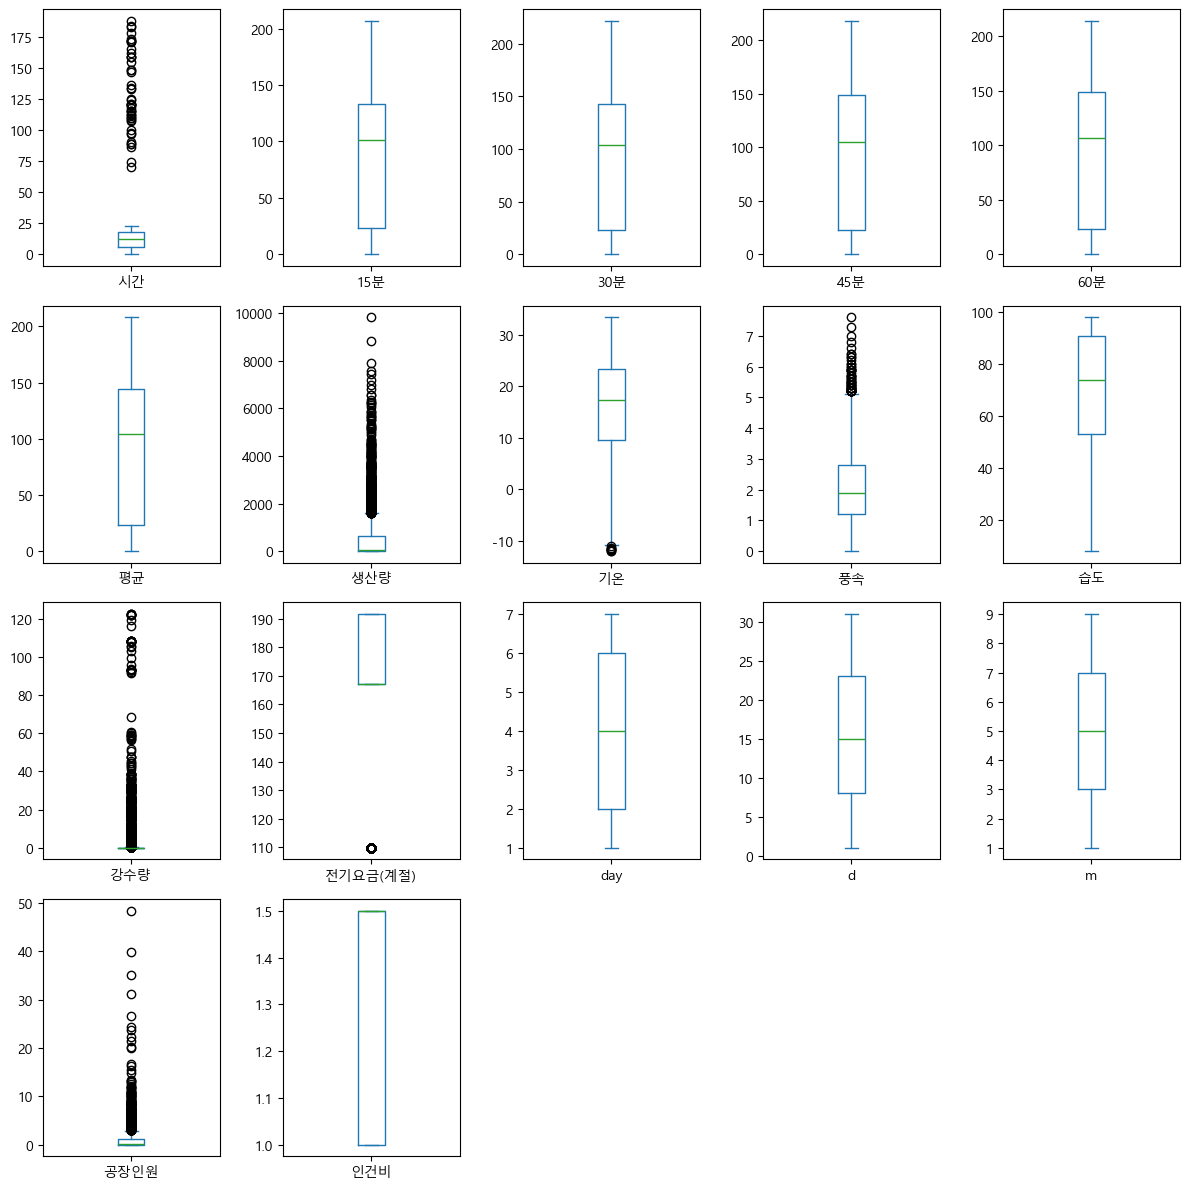

In [10]:
# 일자는 제외
# sns.boxplot(data=power_df.drop(columns=['날짜', '생산량']))
# plt.title('Seaborn Boxplot')

# 한 줄에 5개씩 배치 (열 개수에 맞춰 행 수는 자동 계산)
df = power_df.drop(columns=['날짜'])
df.plot(kind='box', subplots=True, layout=(-1, 5), figsize=(12, 12))
plt.tight_layout()
plt.show()

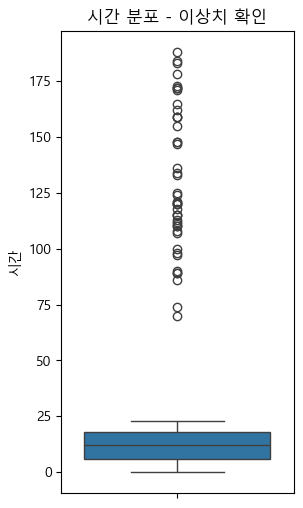

In [11]:
plt.figure(figsize=(3, 6))
sns.boxplot(data=power_df['시간'])
plt.title('시간 분포 - 이상치 확인')
plt.show()

### 시간 정보가 잘못됨

In [12]:
power_df['시간'].unique(), len(power_df['시간'].unique())

# print(len(power_df['시간'].unique()))

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  70,  89,
         90,  97, 107, 108, 112, 113, 115, 118, 120, 121, 124, 133, 136,
        148, 155, 159, 165, 171, 172, 188,  74,  86,  98, 100, 110, 111,
        125, 134, 147, 162, 173, 178, 183, 184]),
 60)

In [11]:
# 시간 정보 오류 확인 및 수정

err_df = power_df[(power_df['시간'] < 0) | (power_df['시간'] > 23)].copy()

err_df
# err_df.count()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
4632,20210713,70,70,69,69,69,69,0,25.1,2.0,98,0.0,191.6,2,13,7,0.0,1.5
4633,20210713,89,77,93,119,94,96,0,25.0,1.3,97,0.0,191.6,2,13,7,0.0,1.5
4634,20210713,90,117,110,114,107,112,0,24.9,1.5,96,0.0,191.6,2,13,7,0.0,1.5
4635,20210713,97,115,107,112,107,110,0,24.7,0.4,96,0.0,191.6,2,13,7,0.0,1.5
4636,20210713,107,106,112,101,106,106,0,24.5,1.4,96,0.0,191.6,2,13,7,0.0,1.5
4637,20210713,108,121,153,162,136,143,0,24.7,0.2,96,0.0,191.6,2,13,7,0.0,1.5
4638,20210713,112,125,124,121,120,123,0,25.8,1.0,93,0.0,191.6,2,13,7,0.0,1.5
4639,20210713,113,112,107,113,111,111,0,27.5,1.0,84,0.0,191.6,2,13,7,0.0,1.5
4640,20210713,115,112,110,81,104,102,0,29.2,1.9,73,0.0,191.6,2,13,7,0.0,1.5
4641,20210713,118,105,118,112,113,112,0,29.3,3.0,69,0.0,191.6,2,13,7,0.0,1.5


In [12]:
err_df['날짜'].value_counts()

날짜
20210713    24
20210715    24
Name: count, dtype: int64

###  날짜 오류 수정을 위한 데이타 확인 및 테스트

In [13]:
err_df['날짜'].unique().tolist()

[20210713, 20210715]

In [14]:
for date in err_df['날짜'].unique().tolist() :
    err_df.loc[err_df['날짜'] == date, '시간'] = np.arange(24)

err_df[['날짜', '시간']]

,날짜,시간
4632,20210713,0
4633,20210713,1
4634,20210713,2
4635,20210713,3
4636,20210713,4
4637,20210713,5
4638,20210713,6
4639,20210713,7
4640,20210713,8
4641,20210713,9


###  날짜 오류 수정 반영

In [15]:
err_dates = err_df['날짜'].unique().tolist()
for date in err_df['날짜'].unique().tolist() :
    power_df.loc[power_df['날짜'] == date, '시간'] = np.arange(24)

power_df.loc[power_df['날짜'].isin(err_dates), ['날짜','시간']]

,날짜,시간
4632,20210713,0
4633,20210713,1
4634,20210713,2
4635,20210713,3
4636,20210713,4
4637,20210713,5
4638,20210713,6
4639,20210713,7
4640,20210713,8
4641,20210713,9


In [18]:
power_df['시간'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

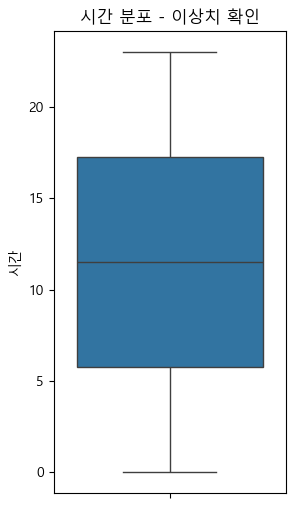

In [19]:
plt.figure(figsize=(3, 6))
sns.boxplot(data=power_df['시간'])
plt.title('시간 분포 - 이상치 확인')
plt.show()

In [20]:
power_df.corr()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
날짜,1.000000e+00,-5.187585e-14,0.035555,0.034746,0.037285,0.036244,0.036572,0.070719,0.863028,-0.267877,0.548722,0.160855,8.358358e-01,-1.183774e-02,-3.521020e-02,9.993569e-01,-0.002136,0.005469
시간,-5.187585e-14,1.000000e+00,0.124191,0.112568,0.101041,0.076296,0.104344,0.132111,0.109343,0.097169,-0.145032,0.122523,1.083940e-15,-5.182983e-18,3.872564e-18,1.634985e-15,0.084077,-0.166807
15분,3.555450e-02,1.241908e-01,1.000000,0.980295,0.966859,0.950034,0.984688,0.520424,0.050760,0.115016,-0.085205,-0.008241,5.588134e-02,-4.283119e-01,5.255441e-02,3.360101e-02,0.295909,-0.202557
30분,3.474601e-02,1.125677e-01,0.980295,1.000000,0.982443,0.959004,0.991255,0.515841,0.049524,0.113965,-0.084102,-0.010410,5.620322e-02,-4.266740e-01,5.575440e-02,3.267924e-02,0.288622,-0.195760
45분,3.728511e-02,1.010415e-01,0.966859,0.982443,1.000000,0.984789,0.994774,0.513789,0.052818,0.115627,-0.082522,-0.013136,5.904420e-02,-4.329573e-01,5.604744e-02,3.520298e-02,0.286091,-0.211635
60분,3.624374e-02,7.629631e-02,0.950034,0.959004,0.984789,1.000000,0.984828,0.499723,0.055651,0.128467,-0.090875,-0.014812,5.787812e-02,-4.375765e-01,5.635399e-02,3.415260e-02,0.276778,-0.243434
평균,3.657182e-02,1.043443e-01,0.984688,0.991255,0.994774,0.984828,1.000000,0.517948,0.052996,0.119667,-0.086508,-0.011759,5.809601e-02,-4.362798e-01,5.582355e-02,3.449909e-02,0.289860,-0.215982
생산량,7.071926e-02,1.321111e-01,0.520424,0.515841,0.513789,0.499723,0.517948,1.000000,0.117780,0.115388,-0.109503,0.008171,6.892961e-02,-2.591290e-01,4.483612e-02,6.897566e-02,0.785115,-0.280625
기온,8.630283e-01,1.093433e-01,0.050760,0.049524,0.052818,0.055651,0.052996,0.117780,1.000000,-0.192028,0.401553,0.118524,8.098254e-01,1.012953e-02,1.084866e-01,8.574903e-01,0.030540,-0.184611
풍속,-2.678775e-01,9.716902e-02,0.115016,0.113965,0.115627,0.128467,0.119667,0.115388,-0.192028,1.000000,-0.439745,0.049009,-2.541913e-01,3.896542e-03,-1.190186e-02,-2.669439e-01,0.088701,-0.349769


In [21]:
power_df.corr()['평균']

날짜          0.036572
시간          0.104344
15분         0.984688
30분         0.991255
45분         0.994774
60분         0.984828
평균          1.000000
생산량         0.517948
기온          0.052996
풍속          0.119667
습도         -0.086508
강수량        -0.011759
전기요금(계절)    0.058096
day        -0.436280
d           0.055824
m           0.034499
공장인원        0.289860
인건비        -0.215982
Name: 평균, dtype: float64

## 2.3 데이터 현황 조사 : 전력량과 다른 변수들간의 상관관계 
- 우선 15, 30, 45, 60, 평균은 서로 깊은 연관 : 당연한 결과
- 평균전력량을 기준으로 생산량과 연관; 다만 0.52 수준으로 그리 높지는 않음 - 고정 전력량, 공장인원과 생산량과의 상관관계 등의 영향 의심
- 기온, 풍속은은 상대적으로 낮음 (계절별 확인 필요)
- 요일(day)와는 음의 상관관계 : 6, 7 이 토, 일 평일이 1,2,3,4,5 => 주중에 생산량이 높은 것과 연관
- 공장인원은 생산량과 연관되어 같이 높을 수도... : 생산량과 공장인원은 0.785

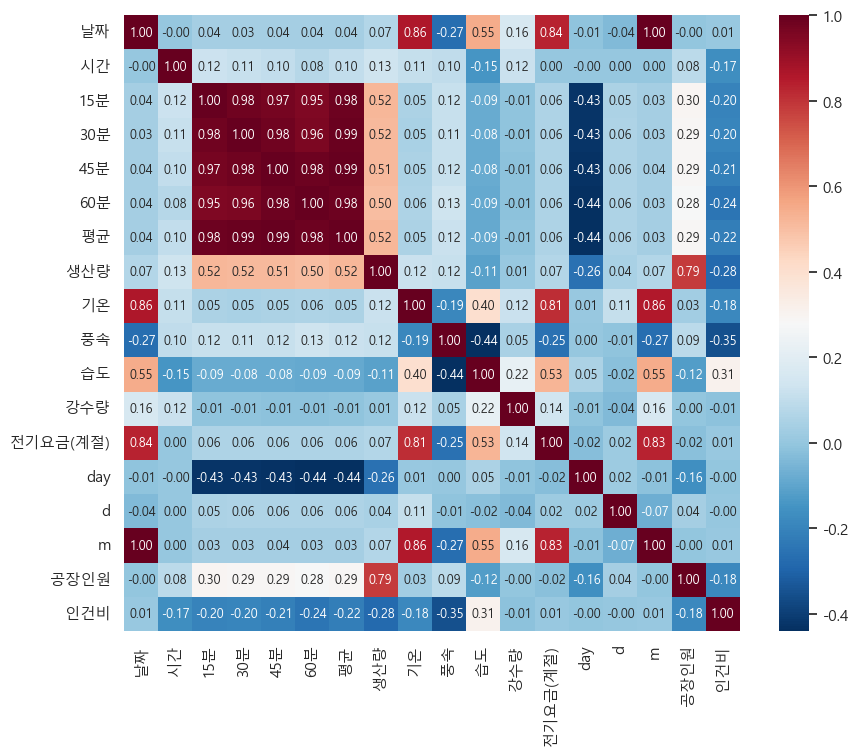

In [22]:
# 1. 그래프 크기와 폰트 설정 (최신 방식)
plt.figure(figsize=(10, 8)) # 화면 크기 확대 (가로 10, 세로 8)
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

# 2. Seaborn 스타일 설정 (set_theme 사용 권장)
sns.set_theme(style="darkgrid", font="Malgun Gothic", rc={"axes.unicode_minus": False})

# 3. 히트맵 그리기
sns.heatmap(
    power_df.corr(), 
    vmax=1, 
    square=True, 
    annot=True, 
    fmt=".2f",          # 소수점 둘레 설정으로 가독성 향상
    annot_kws={'size': 9}, # 글자 크기를 5에서 9로 키움
    cmap='RdBu_r'       # 상관계수 확인에 용이한 컬러맵 추가 (선택사항)
)

plt.show()

## 2.5 데이터 전처리 : 변수 타입 변경 및 파생 변수 추가

### 일자-시간 변수 추가 - Index로 추가

In [17]:
# import datetime

# 1. datehour 컬럼 생성 (문자열로 치환 -> 결합 -> 포맷을 지정하여 datatime 으로 변환)
power_df['datehour'] = pd.to_datetime(
    power_df['날짜'].astype(str) + power_df['시간'].astype(str).str.zfill(2),
    format='%Y%m%d%H'
)

# 2. datetime 컬럼을 인덱스로 설정
# inplace=True를 사용하면 원본 df가 바로 수정됩니다.
power_df = power_df.set_index('datehour', drop=True) # 기존 인데스는 제거(Drop)

power_df

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
datehour,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.000000,1.5
2021-01-01 01:00:00,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.000000,1.5
2021-01-01 02:00:00,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.000000,1.5
2021-01-01 03:00:00,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.000000,1.5
2021-01-01 04:00:00,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.000000,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-14 19:00:00,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
2021-09-14 20:00:00,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
2021-09-14 21:00:00,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5


## 열외 - 전력량 사용량 시각화

### 일자-시간 별 전력 Peak 값 변경 - int54 -> float

In [19]:
peak_df = power_df[['15분',	'30분',	'45분',	'60분',	'평균'	]].astype(float)
peak_df

,15분,30분,45분,60분,평균
datehour,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,61.0
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,105.0
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,104.0
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,105.0
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,107.0
...,...,...,...,...,...
2021-09-14 19:00:00,152.0,151.0,171.0,139.0,153.0
2021-09-14 20:00:00,124.0,130.0,128.0,130.0,128.0
2021-09-14 21:00:00,134.0,130.0,125.0,124.0,128.0


### 평균값 다시 계산

In [20]:
peak_df['평균'] = power_df[['15분',	'30분',	'45분',	'60분']].mean(axis=1)
peak_df

,15분,30분,45분,60분,평균
datehour,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,61.25
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,104.50
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,103.75
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,105.25
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,106.75
...,...,...,...,...,...
2021-09-14 19:00:00,152.0,151.0,171.0,139.0,153.25
2021-09-14 20:00:00,124.0,130.0,128.0,130.0,128.00
2021-09-14 21:00:00,134.0,130.0,125.0,124.0,128.25


### 전력 Peak 사용량 시각화

In [21]:
sns.set(rc={
    "figure.figsize": (20, 10),
    "font.family": "Malgun Gothic",  # 윈도우용 폰트
    "axes.unicode_minus": False     # 마이너스 기호 깨짐 방지
})

* 2021년 전체

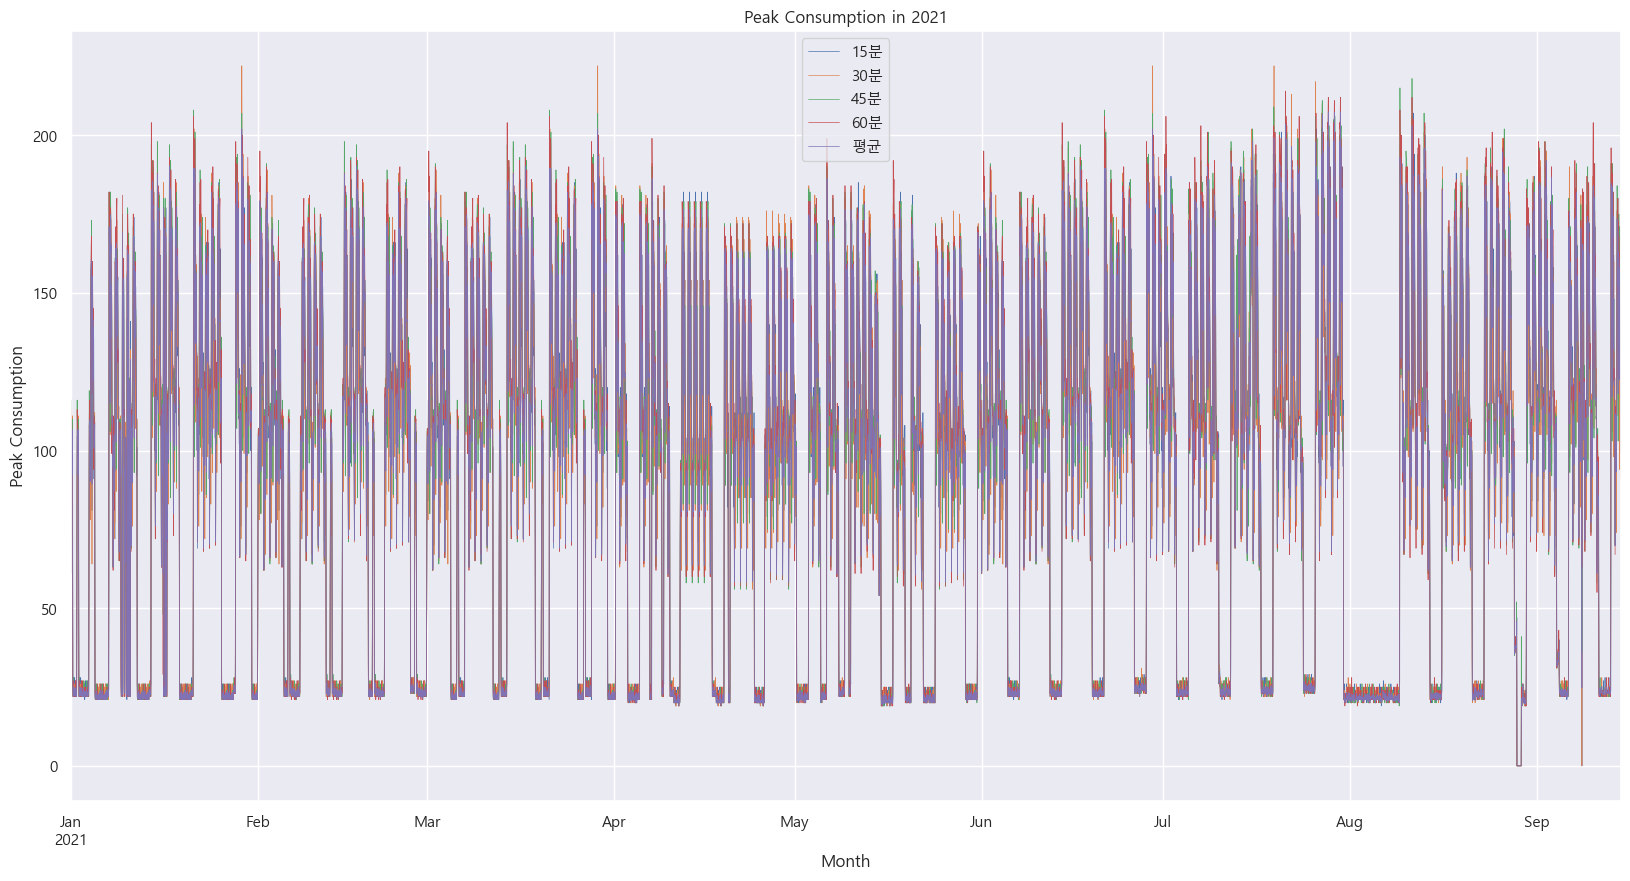

In [27]:
peak_df.plot(linewidth = 0.5);
plt.title("Peak Consumption in 2021")
plt.xlabel("Month")
plt.ylabel("Peak Consumption")
plt.show()

In [22]:
off_df = power_df[(power_df['생산량']==0) & (power_df['평균']<30)& (power_df['day']<6) & (power_df['시간']==10)]
off_df

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
datehour,,,,,,,,,,,,,,,,,,
2021-01-01 10:00:00,20210101,10,22,22,22,22,22,0,-1.2,2.1,54,0.0,109.8,5,1,1,0.0,1.0
2021-01-05 10:00:00,20210105,10,21,21,22,26,23,0,4.1,2.0,64,0.0,109.8,2,5,1,0.0,1.0
2021-01-06 10:00:00,20210106,10,21,21,22,26,23,0,-4.7,3.5,45,0.0,109.8,3,6,1,0.0,1.0
2021-01-12 10:00:00,20210112,10,21,21,22,26,23,0,-0.3,1.5,53,0.0,109.8,2,12,1,0.0,1.0
2021-01-13 10:00:00,20210113,10,21,21,22,26,23,0,4.6,0.3,52,0.0,109.8,3,13,1,0.0,1.0
2021-01-19 10:00:00,20210119,10,21,21,22,26,23,0,-3.1,2.1,43,0.0,109.8,2,19,1,0.0,1.0
2021-01-20 10:00:00,20210120,10,21,21,22,26,23,0,3.8,1.3,28,0.0,109.8,3,20,1,0.0,1.0
2021-01-26 10:00:00,20210126,10,21,21,22,26,23,0,7.2,1.6,98,3.0,109.8,2,26,1,0.0,1.0
2021-01-27 10:00:00,20210127,10,21,21,22,26,23,0,5.5,3.1,58,0.0,109.8,3,27,1,0.0,1.0


* 2021년 8월 통계

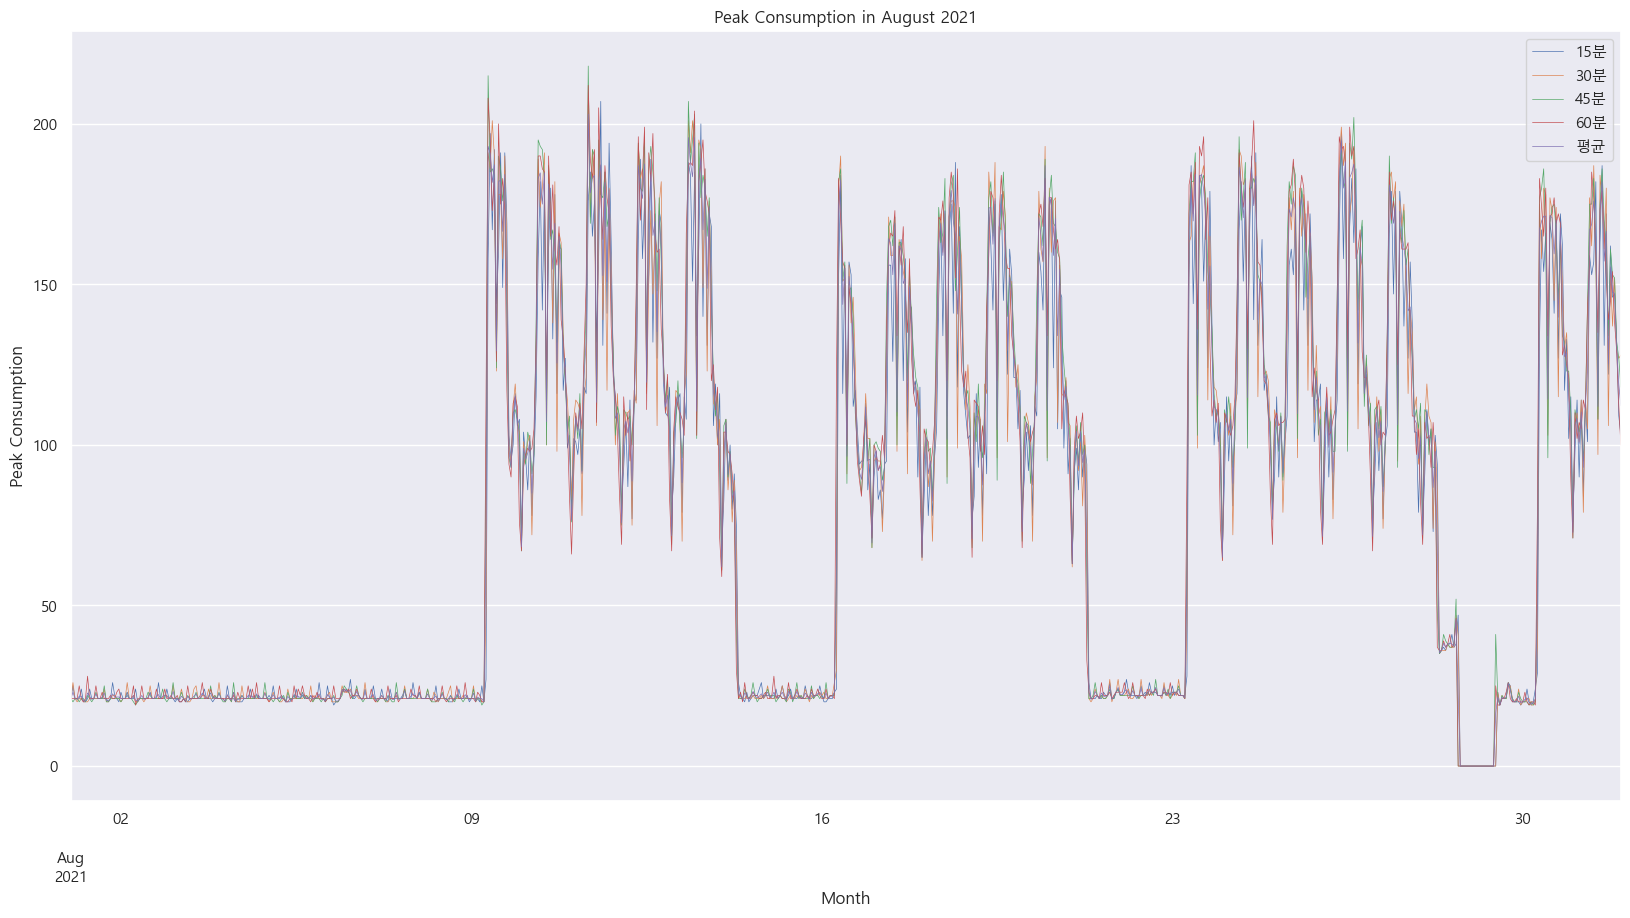

In [29]:
peak_df.loc['2021-08'].plot(linewidth = 0.5);
plt.title("Peak Consumption in August 2021")
plt.xlabel("Month")
plt.ylabel("Peak Consumption")
plt.show()

** 8월 첫주 공장 휴가로 추정

* 2021년 1월 1일 추이

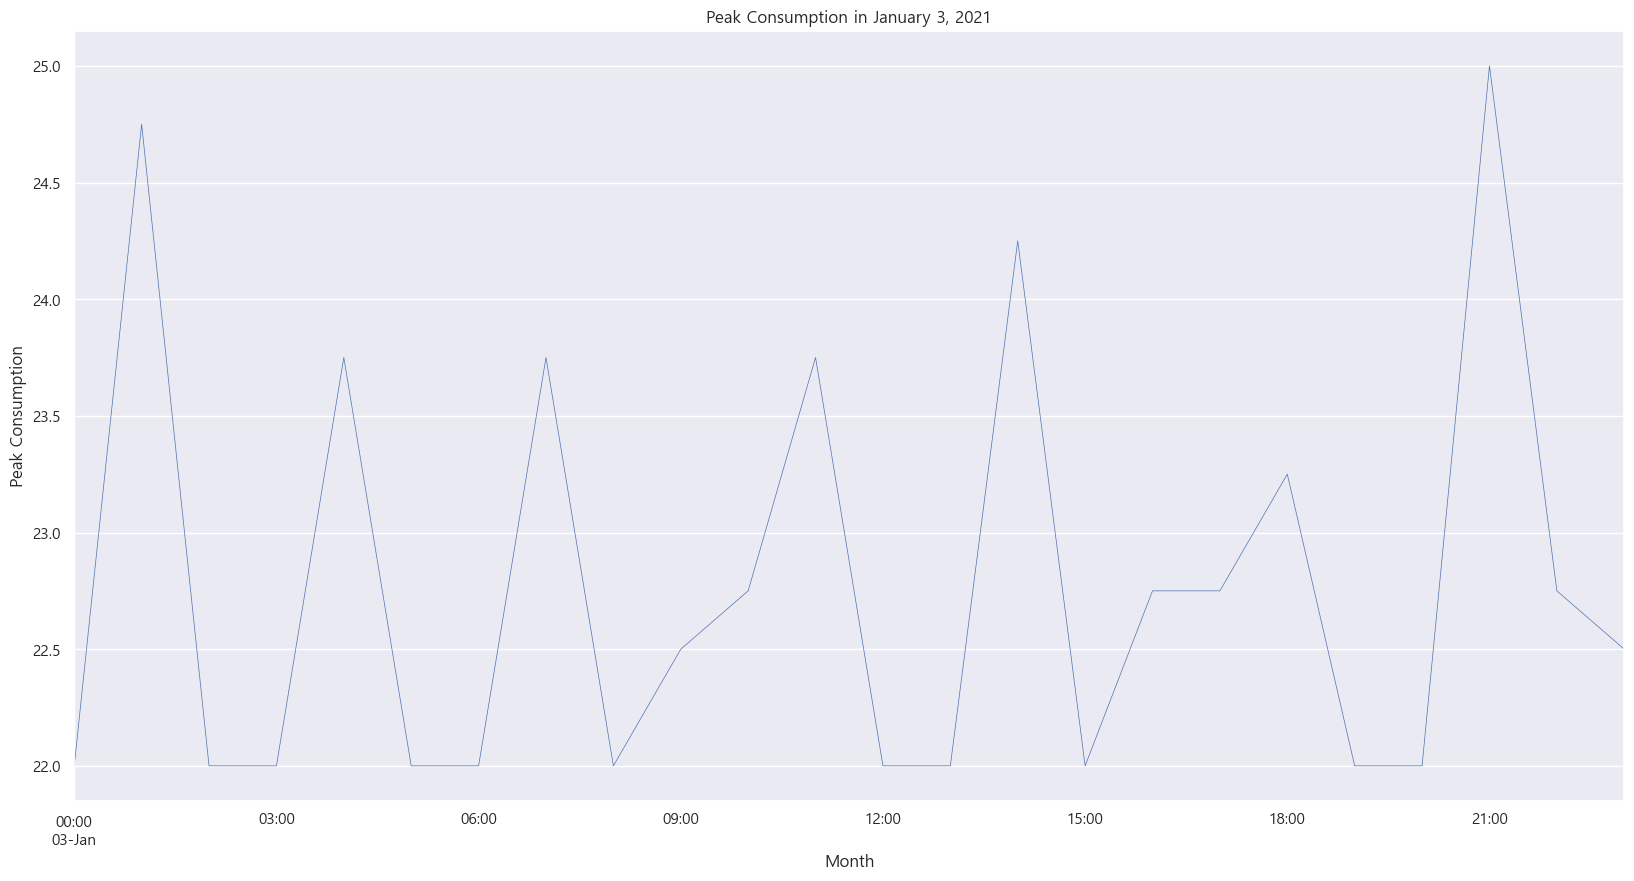

In [30]:
# peak_df.loc['2021-01-01'].plot(linewidth = 0.5)
peak_df.loc['2021-01-03']['평균'].plot(linewidth = 0.5)
plt.title("Peak Consumption in January 3, 2021")
plt.xlabel("Month")
plt.ylabel("Peak Consumption")
plt.show()

## (끝) 열외 - 전력량 사용량 시각화 

### 파생변수 추가 - 주말 및 공휴일

In [23]:
from datetime import datetime

datetime.strptime('2021-01-01', '%Y-%m-%d').weekday()  # 월요일 부터 0으로 시작 - 일요일 6

datetime.now().isoweekday()  # 월요일 부터 1으로 시작 - 일요일 7

7

In [24]:
# 주말 추가 : 토, 일 - 통상 휴무일
power_df['weekend'] = np.where(power_df['day'] > 5, 1, 0)

# 법정 공휴일 및 하계휴가일
holidays = ["2021-01-01", "2021-02-11", "2021-02-12","2021-03-01", "2021-05-05", "2021-05-19", "2021-08-16"]  # 9월 이후 데이터는 생략 
holidays += ["2021-08-02", "2021-08-03", "2021-08-04","2021-08-05"]  # 공장 휴뮤일 추가

# 인덱스의 날짜 부분만 문자열로 바꿔서 리스트와 비교
power_df['holiday'] = power_df.index.strftime('%Y-%m-%d').isin(holidays).astype(int)

power_df

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비,weekend,holiday
datehour,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.000000,1.5,0,1
2021-01-01 01:00:00,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.000000,1.5,0,1
2021-01-01 02:00:00,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.000000,1.5,0,1
2021-01-01 03:00:00,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.000000,1.5,0,1
2021-01-01 04:00:00,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.000000,1.5,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-14 19:00:00,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5,0,0
2021-09-14 20:00:00,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5,0,0
2021-09-14 21:00:00,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5,0,0


### 중복 또는 여분(Redundant) 속성 삭제
- 날짜, 평균

In [74]:
power_df = power_df.drop(columns=['날짜', '평균'], errors='ignore')
power_df

,시간,15분,30분,45분,60분,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비,weekend,holiday
datehour,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,0,62,61,61,61,0.000000,-3.2,0.279126,71,0.000000,109.8,5,1,1,0.000000,1.5,0,1
2021-01-01 01:00:00,1,96,93,116,113,0.000000,-4.5,0.257199,77,0.000000,109.8,5,1,1,0.000000,1.5,0,1
2021-01-01 02:00:00,2,106,96,106,107,0.000000,-3.9,0.282398,58,0.000000,109.8,5,1,1,0.000000,1.5,0,1
2021-01-01 03:00:00,3,92,110,110,109,0.000000,-4.1,0.282398,56,0.000000,109.8,5,1,1,0.000000,1.5,0,1
2021-01-01 04:00:00,4,108,105,106,108,0.000000,-4.6,0.282398,60,0.000000,109.8,5,1,1,0.000000,1.5,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-14 19:00:00,19,152,151,171,139,0.370104,21.7,0.294453,85,0.320614,167.2,2,14,9,0.279847,1.5,0,0
2021-09-14 20:00:00,20,124,130,128,130,0.345175,22.2,0.299522,78,0.320614,167.2,2,14,9,0.067413,1.5,0,0
2021-09-14 21:00:00,21,134,130,125,124,0.356448,22.2,0.300262,76,0.320614,167.2,2,14,9,0.146398,1.5,0,0


In [26]:
power_df.corr()

,시간,15분,30분,45분,60분,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비,weekend,holiday
시간,1.000000e+00,0.124191,0.112568,0.101041,0.076296,0.132111,0.109343,0.097169,-0.145032,0.122523,1.083940e-15,-5.182983e-18,3.872564e-18,1.634985e-15,0.084077,-0.166807,-5.053555e-19,9.044081e-17
15분,1.241908e-01,1.000000,0.980295,0.966859,0.950034,0.520424,0.050760,0.115016,-0.085205,-0.008241,5.588134e-02,-4.283119e-01,5.255441e-02,3.360101e-02,0.295909,-0.202557,-5.138289e-01,-1.357573e-01
30분,1.125677e-01,0.980295,1.000000,0.982443,0.959004,0.515841,0.049524,0.113965,-0.084102,-0.010410,5.620322e-02,-4.266740e-01,5.575440e-02,3.267924e-02,0.288622,-0.195760,-5.111349e-01,-1.352719e-01
45분,1.010415e-01,0.966859,0.982443,1.000000,0.984789,0.513789,0.052818,0.115627,-0.082522,-0.013136,5.904420e-02,-4.329573e-01,5.604744e-02,3.520298e-02,0.286091,-0.211635,-5.208535e-01,-1.375502e-01
60분,7.629631e-02,0.950034,0.959004,0.984789,1.000000,0.499723,0.055651,0.128467,-0.090875,-0.014812,5.787812e-02,-4.375765e-01,5.635399e-02,3.415260e-02,0.276778,-0.243434,-5.242898e-01,-1.385533e-01
생산량,1.321111e-01,0.520424,0.515841,0.513789,0.499723,1.000000,0.117780,0.115388,-0.109503,0.008171,6.892961e-02,-2.591290e-01,4.483612e-02,6.897566e-02,0.785115,-0.280625,-3.172421e-01,-1.008455e-01
기온,1.093433e-01,0.050760,0.049524,0.052818,0.055651,0.117780,1.000000,-0.192028,0.401553,0.118524,8.098254e-01,1.012953e-02,1.084866e-01,8.574903e-01,0.030540,-0.184611,2.444836e-02,5.594888e-02
풍속,9.716902e-02,0.115016,0.113965,0.115627,0.128467,0.115388,-0.192028,1.000000,-0.439745,0.049009,-2.541913e-01,3.896542e-03,-1.190186e-02,-2.669439e-01,0.088701,-0.349769,2.863693e-02,-5.210327e-02
습도,-1.450321e-01,-0.085205,-0.084102,-0.082522,-0.090875,-0.109503,0.401553,-0.439745,1.000000,0.219997,5.255203e-01,5.281977e-02,-2.305278e-02,5.485028e-01,-0.121135,0.308435,3.238296e-02,3.434412e-02
강수량,1.225228e-01,-0.008241,-0.010410,-0.013136,-0.014812,0.008171,0.118524,0.049009,0.219997,1.000000,1.393468e-01,-7.520445e-03,-3.569401e-02,1.618289e-01,-0.004847,-0.012680,3.168007e-02,-5.015457e-03


# 3. 데이터 분석 - Random Forest

In [30]:
power_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 6168 entries, 2021-01-01 00:00:00 to 2021-09-14 23:00:00
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   시간        6168 non-null   int64  
 1   15분       6168 non-null   int64  
 2   30분       6168 non-null   int64  
 3   45분       6168 non-null   int64  
 4   60분       6168 non-null   int64  
 5   생산량       6168 non-null   int64  
 6   기온        6168 non-null   float64
 7   풍속        6165 non-null   float64
 8   습도        6168 non-null   int64  
 9   강수량       6168 non-null   float64
 10  전기요금(계절)  6168 non-null   float64
 11  day       6168 non-null   int64  
 12  d         6168 non-null   int64  
 13  m         6168 non-null   int64  
 14  공장인원      6168 non-null   float64
 15  인건비       6168 non-null   float64
 16  weekend   6168 non-null   int64  
 17  holiday   6168 non-null   int64  
dtypes: float64(6), int64(12)
memory usage: 915.6 KB


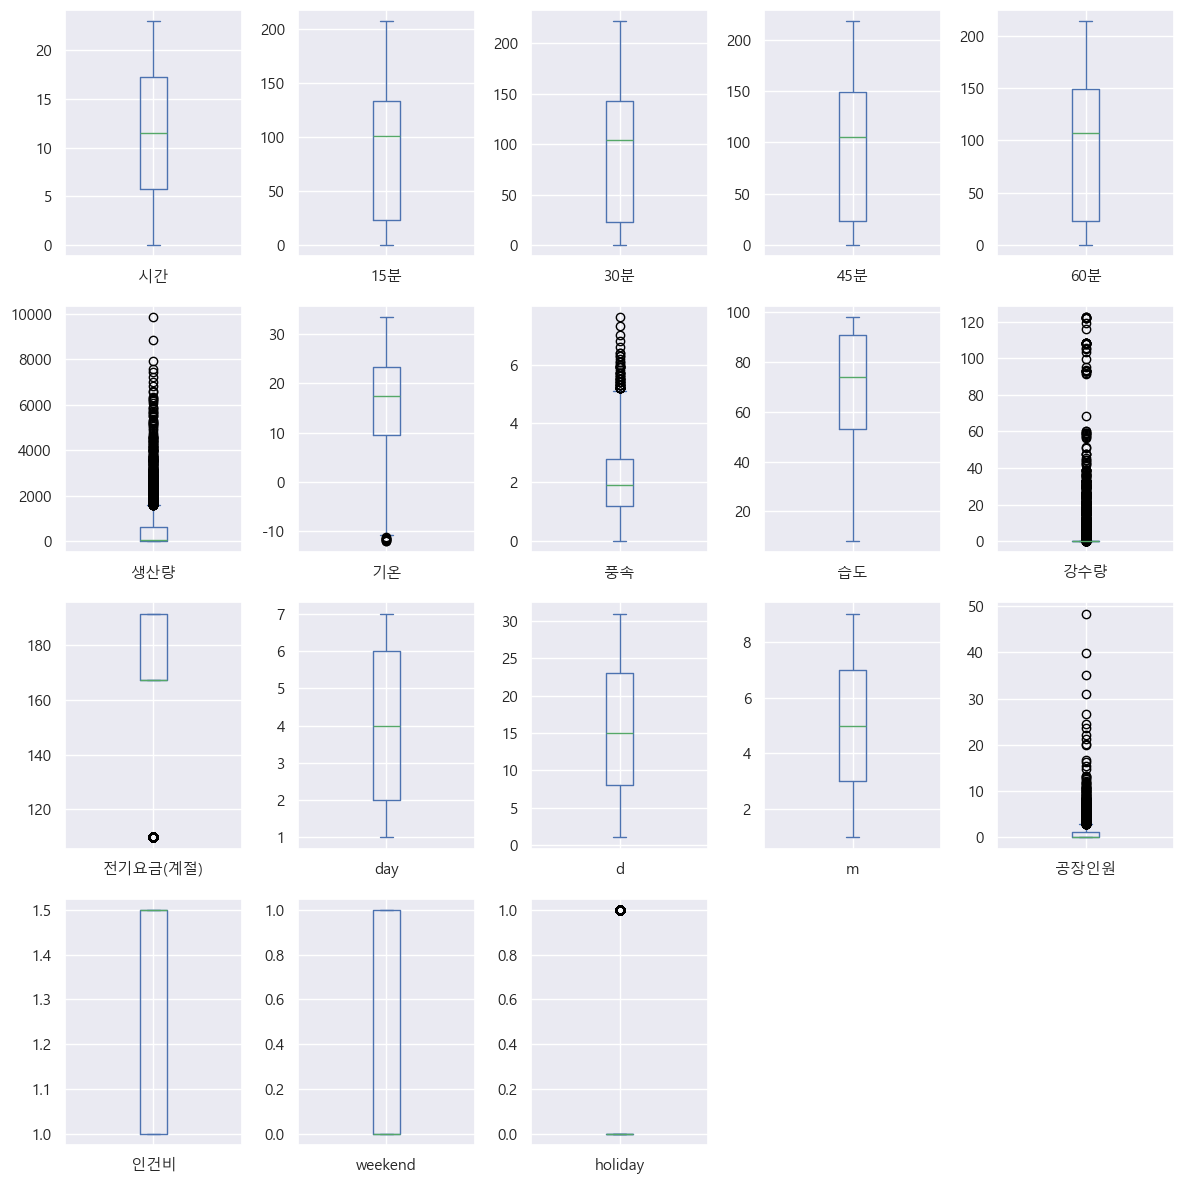

In [32]:
power_df.plot(kind='box', subplots=True, layout=(-1, 5), figsize=(12, 12))
plt.tight_layout()
plt.show()

* 생산량, 강수량, 공장인원은 log 함수 적용

In [28]:
len(power_df)

6168

## 3.1 데이터 로그 적용 및 데이터 분리

In [ ]:
# 데이터 컬럼 분류

# log 함수 적용 컬럼
log_features = ['생산량', '강수량', '공장인원', '풍속']

# X
source_features = ['시간', '생산량', '기온', '풍속', '습도', '강수량', 'day', 'd', 'm', 'weekend', 'holiday']
source_features_blind = ['시간', '기온', '풍속', '습도', '강수량', 'day', 'd', 'm', 'weekend', 'holiday']  # '생산량' 이 빠짐 (깜깜이 예측)

# y
target_features = ['15분', '30분', '45분', '60분']

# C : 행후 생산량에 따른 비용 최적화
cost_features = ['생산량', '전기요금(계절)', '공장인원', '인건비']


** 일자별로 테스트 데이터 분리

In [85]:
power_df.index.normalize().unique()  # 일자만 추출

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04',
               '2021-01-05', '2021-01-06', '2021-01-07', '2021-01-08',
               '2021-01-09', '2021-01-10',
               ...
               '2021-09-05', '2021-09-06', '2021-09-07', '2021-09-08',
               '2021-09-09', '2021-09-10', '2021-09-11', '2021-09-12',
               '2021-09-13', '2021-09-14'],
              dtype='datetime64[us]', name='datehour', length=257, freq=None)

In [86]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# 1. 데이터 전처리 - 우상향 데이터에 대한 로그함수 적용
for col in log_features:
    power_df[col] = np.log1p(power_df[col])

#2. 독립변수와 종속변수 구분
X = power_df[source_features]
y = power_df[target_features]

C = power_df[cost_features]

#3 학습데이터와 테스트 데아터로 분리 - 일자별로 분리
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 고유 날짜 추출 (index가 datetime 형식일 때)
unique_dates = power_df.index.normalize().unique() 

# 4. 날짜를 8:2로 분할
train_dates, test_dates = train_test_split(unique_dates, test_size=0.3, random_state=42)

# 5. 날짜 리스트를 기준으로 마스크 생성 및 데이터 분리
train_mask = power_df.index.normalize().isin(train_dates)
test_mask = power_df.index.normalize().isin(test_dates)

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]
y_train = y.loc[train_mask]
y_test = y.loc[test_mask]


In [87]:
X_test

,시간,생산량,기온,풍속,습도,강수량,day,d,m,weekend,holiday
datehour,,,,,,,,,,,
2021-01-07 00:00:00,0,0.000000,-2.2,0.171121,53,0.0,4,7,1,0,0
2021-01-07 01:00:00,1,0.229331,-2.3,0.183262,55,0.0,4,7,1,0,0
2021-01-07 02:00:00,2,0.000000,-1.2,0.204607,55,0.0,4,7,1,0,0
2021-01-07 03:00:00,3,0.231952,-1.0,0.203410,55,0.0,4,7,1,0,0
2021-01-07 04:00:00,4,0.237932,-1.4,0.208429,43,0.0,4,7,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2021-09-13 19:00:00,19,0.243139,22.3,0.195945,78,0.0,1,13,9,0,0
2021-09-13 20:00:00,20,0.223136,22.2,0.183262,78,0.0,1,13,9,0,0
2021-09-13 21:00:00,21,0.233104,21.9,0.193567,77,0.0,1,13,9,0,0


In [88]:
y_test

,15분,30분,45분,60분
datehour,,,,
2021-01-07 00:00:00,22,22,22,25
2021-01-07 01:00:00,26,22,22,22
2021-01-07 02:00:00,22,21,21,22
2021-01-07 03:00:00,22,22,22,23
2021-01-07 04:00:00,22,26,26,23
...,...,...,...,...
2021-09-13 19:00:00,162,160,148,122
2021-09-13 20:00:00,113,122,122,126
2021-09-13 21:00:00,122,131,122,115


## 3.2 Random-Forest 학습 및 최적화

### 1차 최적화 : 시간이 오래 걸림 : 결과만 확인해도 됨

In [ ]:
# from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# # 2. 1차 GridSearchCV 설정 (범위를 넓게 잡음)
# rf = RandomForestRegressor(random_state=42)

# param_grid = {
#     'n_estimators': [100, 300, 500],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'max_features': [None, 'sqrt', 'log2']
# }

# grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
# grid_search.fit(X_train, y_train)

# # 3. 결과 확인
# print("--- 1차 최적 파라미터 ---")
# print(grid_search.best_params_)
# best_params = grid_search.best_params_
# best_model = grid_search.best_estimator_

# # 4. 최적 모델 추출 및 평가
# y_pred = best_model.predict(X_test)

# print(f"최종 MAE: {mean_absolute_error(y_test, y_pred):.4f}")
# print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
# print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

--- 1차 최적 파라미터 ---
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
최종 MAE: 18.2605
RMSE: 28.5201
R2 Score: 0.7392


### 2차 최적화 : 이전 최적화 파라미터에서 일부만 조정

In [117]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1차 최적화 데이터를 이용하여, 최적화 대상 조정 : 이전 최적화 파라미터 이용
inital_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=20, 
    min_samples_split=10,
    max_features='sqrt',
    random_state=42
)

# 특정 파라미터(들)에 대하 세부 조정 최적화
param_grid_update = {
    'n_estimators': [100, 150],       # 최적값 세분화
    'max_depth': [15, 20, 25],         # 깊이를 좀 더 세분화
    'min_samples_split': [10],       # 기존 최적화 값 인용
    'max_features': [None, 'sqrt']          # 기존 최적화 값 인용
}

# 2차 GridSearchCV 진행
grid_search_final = GridSearchCV(inital_model, param_grid_update, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search_final.fit(X_train, y_train)

# 최종 모델 평가
rf_model = grid_search_final.best_estimator_
y_pred = rf_model.predict(X_test)

print("--- 최종 최적 파라미터 ---")
print(grid_search_final.best_params_)
print(f"최종 MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"최종 RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"최종 R2 Score: {r2_score(y_test, y_pred):.4f}")

--- 최종 최적 파라미터 ---
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
최종 MAE: 18.2605
최종 RMSE: 28.5201
최종 R2 Score: 0.7392


* 최적화 값 변동 사항 없음

## 세부 종속 변수별 성능값 확인

In [93]:

# 각 변수별 성능 지표 계산
maes = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
rmses = np.sqrt(mean_squared_error(y_test, y_pred, multioutput='raw_values'))
r2s = r2_score(y_test, y_pred, multioutput='raw_values')

# 컬럼명과 매칭하여 출력
for col, mae, rmse, r2 in zip(target_features, maes, rmses, r2s):
    print(f"[{col}] MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

[15분] MAE: 18.3513, RMSE: 27.5719, R2: 0.7322
[30분] MAE: 18.6290, RMSE: 28.7389, R2: 0.7363
[45분] MAE: 17.9401, RMSE: 29.0203, R2: 0.7407
[60분] MAE: 18.1216, RMSE: 28.7274, R2: 0.7477


In [94]:
y_pred

array([[ 42.43901371,  42.41421011,  43.60156091,  43.8188749 ],
       [ 53.72630337,  55.09780186,  57.21133518,  58.10038616],
       [ 41.95945145,  42.07588805,  43.47960741,  44.31727346],
       ...,
       [116.80539452, 118.16614958, 120.3364435 , 121.96034588],
       [108.79718688, 114.8730695 , 115.98803549, 115.8106909 ],
       [117.30196092, 119.42775265, 121.92061139, 114.09016501]],
      shape=(1872, 4))

## 3.3 테스트값과 예측값 비교 - 시각화

테스트 값과 예측값 합치기

In [95]:
# 원본 보존을 위해 복사본 생성 (선택 사항)
results_df = y_test.copy()

# y_pred(numpy array)의 각 열을 '{기존열이름}_예측'으로 추가
for i, col in enumerate(target_features):
    results_df[f"{col}_예측"] = y_pred[:, i]

# 확인
print(results_df.head())

                     15분  30분  45분  60분     15분_예측     30분_예측     45분_예측  \
datehour                                                                   
2021-01-07 00:00:00   22   22   22   25  42.439014  42.414210  43.601561   
2021-01-07 01:00:00   26   22   22   22  53.726303  55.097802  57.211335   
2021-01-07 02:00:00   22   21   21   22  41.959451  42.075888  43.479607   
2021-01-07 03:00:00   22   22   22   23  61.480251  62.796573  65.194412   
2021-01-07 04:00:00   22   26   26   23  69.381741  70.659475  74.178378   

                        60분_예측  
datehour                        
2021-01-07 00:00:00  43.818875  
2021-01-07 01:00:00  58.100386  
2021-01-07 02:00:00  44.317273  
2021-01-07 03:00:00  66.674690  
2021-01-07 04:00:00  77.460339  


### 비교의 단순화를 위해 최대값만 비교
* 예를 들어, 30분에서 최대값이면 '30분_예측' 값을 '최대_예측' 값으로 설정

In [96]:
# 1. 실제값 중 최대값과 해당 시점(컬럼명) 찾기
results_df['최대'] = results_df[target_features].max(axis=1)
max_col_names = results_df[target_features].idxmax(axis=1) # 각 행별 최대값의 컬럼명 (예: '30분')

# 2. '최대_예측' 컬럼 생성: 각 행의 최대 시점에 해당하는 예측값 추출
# lookup 방식이나 apply를 활용하여 매칭된 예측 컬럼값을 가져옵니다.
results_df['최대_예측'] = results_df.apply(
    lambda x: x[f"{x.name}_예측"] if isinstance(x.name, str) else x[f"{max_col_names[x.name]}_예측"], 
    axis=1
)

# 더 직관적인 index 기반 방식 (데이터가 클 때 추천)
results_df['최대_예측'] = [results_df.loc[i, f"{col}_예측"] for i, col in zip(results_df.index, max_col_names)]

print(results_df[['최대', '최대_예측']].head())


                     최대      최대_예측
datehour                          
2021-01-07 00:00:00  25  43.818875
2021-01-07 01:00:00  26  53.726303
2021-01-07 02:00:00  22  41.959451
2021-01-07 03:00:00  23  66.674690
2021-01-07 04:00:00  26  70.659475


In [102]:
results_df

,15분,30분,45분,60분,15분_예측,30분_예측,45분_예측,60분_예측,최대,최대_예측
datehour,,,,,,,,,,
2021-01-07 00:00:00,22,22,22,25,42.439014,42.414210,43.601561,43.818875,25,43.818875
2021-01-07 01:00:00,26,22,22,22,53.726303,55.097802,57.211335,58.100386,26,53.726303
2021-01-07 02:00:00,22,21,21,22,41.959451,42.075888,43.479607,44.317273,22,41.959451
2021-01-07 03:00:00,22,22,22,23,61.480251,62.796573,65.194412,66.674690,23,66.674690
2021-01-07 04:00:00,22,26,26,23,69.381741,70.659475,74.178378,77.460339,26,70.659475
...,...,...,...,...,...,...,...,...,...,...
2021-09-13 19:00:00,162,160,148,122,152.148490,148.830932,149.668819,134.576962,162,152.148490
2021-09-13 20:00:00,113,122,122,126,117.134923,119.037667,120.807415,121.746986,126,121.746986
2021-09-13 21:00:00,122,131,122,115,116.805395,118.166150,120.336443,121.960346,131,118.166150


### 시각화 - 당일 최대값과 대응되는 예측값 비교

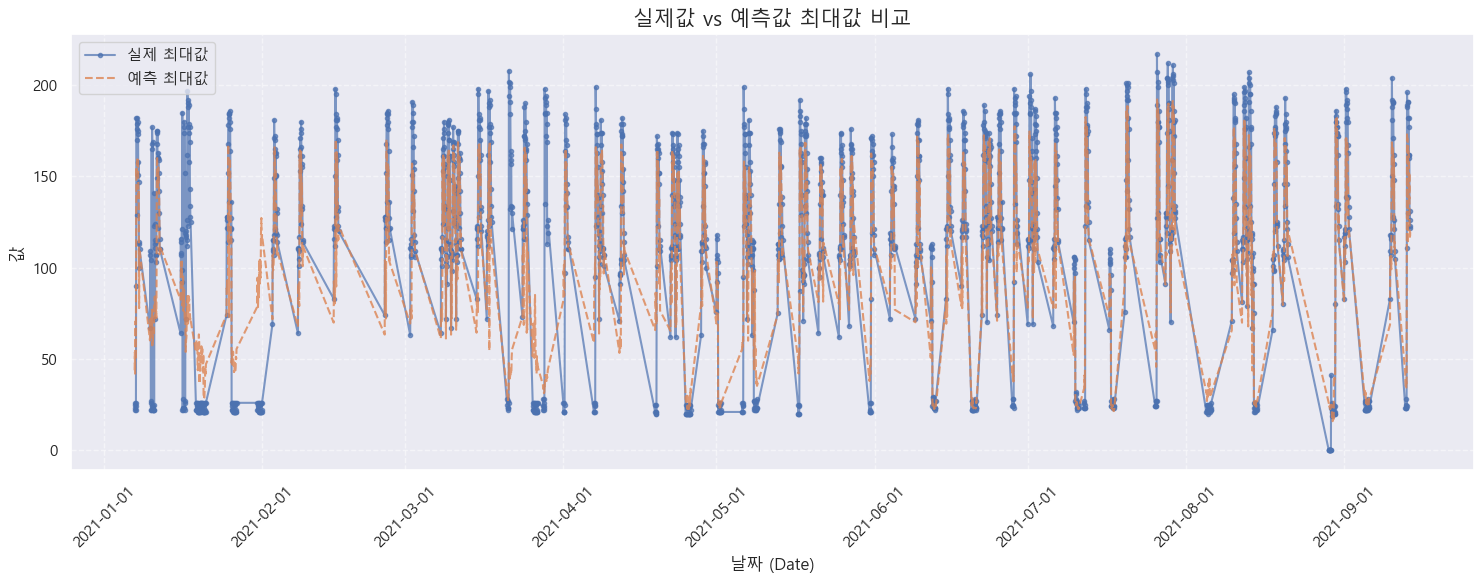

In [97]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 한글 깨짐 방지 (필요 시 설정)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(15, 6))

# 1. 인덱스를 날짜순으로 정렬
results_df = results_df.sort_index()

# 데이터 시각화
plt.plot(results_df.index, results_df['최대'], label='실제 최대값', marker='o', markersize=3, alpha=0.7)
plt.plot(results_df.index, results_df['최대_예측'], label='예측 최대값', linestyle='--', alpha=0.8)

# X축 날짜 간격 설정 (데이터가 많을 경우 대비)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # 자동으로 적절한 간격 선택
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # 날짜 형식 지정

plt.title('실제값 vs 예측값 최대값 비교', fontsize=15)
plt.xlabel('날짜 (Date)', fontsize=12)
plt.ylabel('값', fontsize=12)
plt.xticks(rotation=45) # 날짜 겹침 방지
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


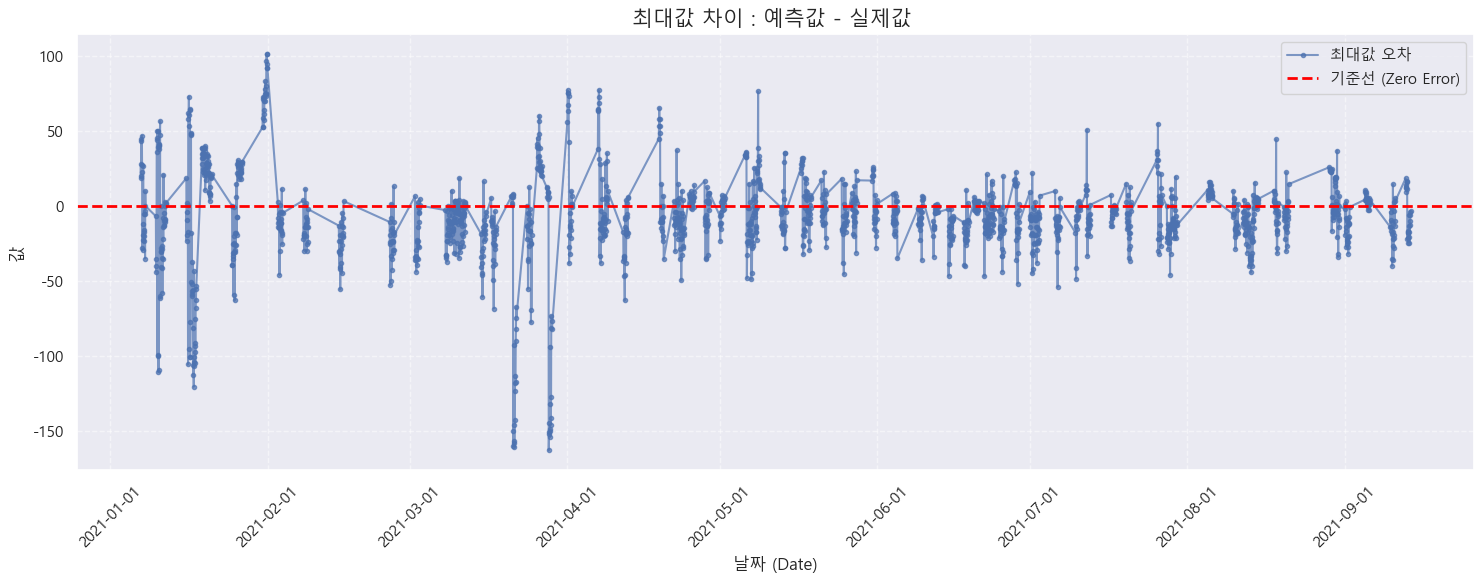

In [101]:
# 한글 깨짐 방지 (필요 시 설정)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(15, 6))

# 1. 인덱스를 날짜순으로 정렬
results_df = results_df.sort_index()

# 데이터 시각화
plt.plot(results_df.index, results_df['최대_예측'] - results_df['최대'], label='최대값 오차', marker='o', markersize=3, alpha=0.7)
# plt.plot(results_df.index, results_df['최대_예측'], label='예측 최대값', linestyle='--', alpha=0.8)

# --- y=0 기준 라인 추가 ---
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='기준선 (Zero Error)')
# -----------------------

# X축 날짜 간격 설정 (데이터가 많을 경우 대비)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # 자동으로 적절한 간격 선택
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # 날짜 형식 지정

plt.title('최대값 차이 : 예측값 - 실제값 ', fontsize=15)
plt.xlabel('날짜 (Date)', fontsize=12)
plt.ylabel('값', fontsize=12)
plt.xticks(rotation=45) # 날짜 겹침 방지
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

### 예측시 각 변수별 중요도

C:\Users\Cherrima\AppData\Local\Temp\ipykernel_13736\1103570837.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


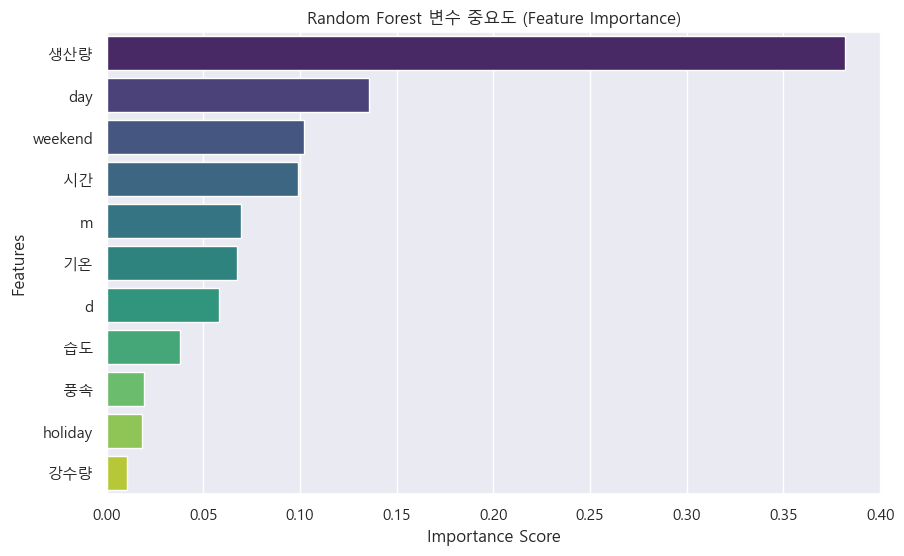

    Feature  Importance
1       생산량    0.381628
6       day    0.135737
9   weekend    0.101964
0        시간    0.098793
8         m    0.069665
2        기온    0.067589
7         d    0.058252
4        습도    0.037985
3        풍속    0.019480
10  holiday    0.018152
5       강수량    0.010755


In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 중요도 추출 및 데이터프레임 변환
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 2. 중요도 순으로 정렬
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# 3. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Random Forest 변수 중요도 (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# 4. 수치로 확인
print(feature_imp_df)

## 3.4 생산량 변수를 제외하고 전력량 예측 (깜깜이 예측 - 시계열 분석과 비교)

In [105]:
XB = power_df[source_features_blind]


XB_train = XB.loc[train_mask]
XB_test = XB.loc[test_mask]

### 최적화 및 확인

In [113]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 2. 1차 GridSearchCV 설정 (범위를 넓게 잡음)
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [8, 10],
    'max_features': [None, 'sqrt']
}

grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(XB_train, y_train)

# 3. 결과 확인
print("--- 1차 최적 파라미터 ---")
print(grid_search.best_params_)
best_params = grid_search.best_params_
blind_model = grid_search.best_estimator_

# 4. 최적 모델 추출 및 평가
y_pred = blind_model.predict(XB_test)

print(f"최종 MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

--- 1차 최적 파라미터 ---
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
최종 MAE: 23.0249
RMSE: 33.9313
R2 Score: 0.6308


### 성능 비교

1. 생산량 포함 예측
- {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
- MAE: 18.2605
- RMSE: 28.5201
- R2 Score: 0.7392

1. 생산량 없이 예측 - 깜깜이
- {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
- MAE: 23.0249
- RMSE: 33.9313
- R2 Score: 0.6308


In [110]:
# 원본 보존을 위해 복사본 생성 (선택 사항)
blind_df = y_test.copy()

# y_pred(numpy array)의 각 열을 '{기존열이름}_예측'으로 추가
for i, col in enumerate(target_features):
    blind_df[f"{col}_예측"] = y_pred[:, i]


# 1. 실제값 중 최대값과 해당 시점(컬럼명) 찾기
blind_df['최대'] = blind_df[target_features].max(axis=1)
max_col_names = blind_df[target_features].idxmax(axis=1) # 각 행별 최대값의 컬럼명 (예: '30분')

# 2. '최대_예측' 컬럼 생성: 각 행의 최대 시점에 해당하는 예측값 추출
# lookup 방식이나 apply를 활용하여 매칭된 예측 컬럼값을 가져옵니다.
blind_df['최대_예측'] = blind_df.apply(
    lambda x: x[f"{x.name}_예측"] if isinstance(x.name, str) else x[f"{max_col_names[x.name]}_예측"], 
    axis=1
)

# 더 직관적인 index 기반 방식 (데이터가 클 때 추천)
blind_df['최대_예측'] = [blind_df.loc[i, f"{col}_예측"] for i, col in zip(blind_df.index, max_col_names)]

print(blind_df[['최대', '최대_예측']].head())

                     최대      최대_예측
datehour                          
2021-01-07 00:00:00  25  43.738094
2021-01-07 01:00:00  26  40.404575
2021-01-07 02:00:00  22  43.597626
2021-01-07 03:00:00  23  45.026362
2021-01-07 04:00:00  26  47.045943


In [112]:
blind_df

,15분,30분,45분,60분,15분_예측,30분_예측,45분_예측,60분_예측,최대,최대_예측
datehour,,,,,,,,,,
2021-01-07 00:00:00,22,22,22,25,41.899141,41.929652,43.417932,43.738094,25,43.738094
2021-01-07 01:00:00,26,22,22,22,40.404575,40.978179,42.128375,42.845123,26,40.404575
2021-01-07 02:00:00,22,21,21,22,43.597626,44.104591,45.396677,46.229325,22,43.597626
2021-01-07 03:00:00,22,22,22,23,42.124778,42.608002,43.894161,45.026362,23,45.026362
2021-01-07 04:00:00,22,26,26,23,47.074152,47.045943,48.542385,49.745627,26,47.045943
...,...,...,...,...,...,...,...,...,...,...
2021-09-13 19:00:00,162,160,148,122,143.781162,142.076941,146.209406,138.675418,162,143.781162
2021-09-13 20:00:00,113,122,122,126,120.169043,124.335608,124.455355,122.316399,126,122.316399
2021-09-13 21:00:00,122,131,122,115,121.469109,124.998594,124.818466,121.936542,131,124.998594


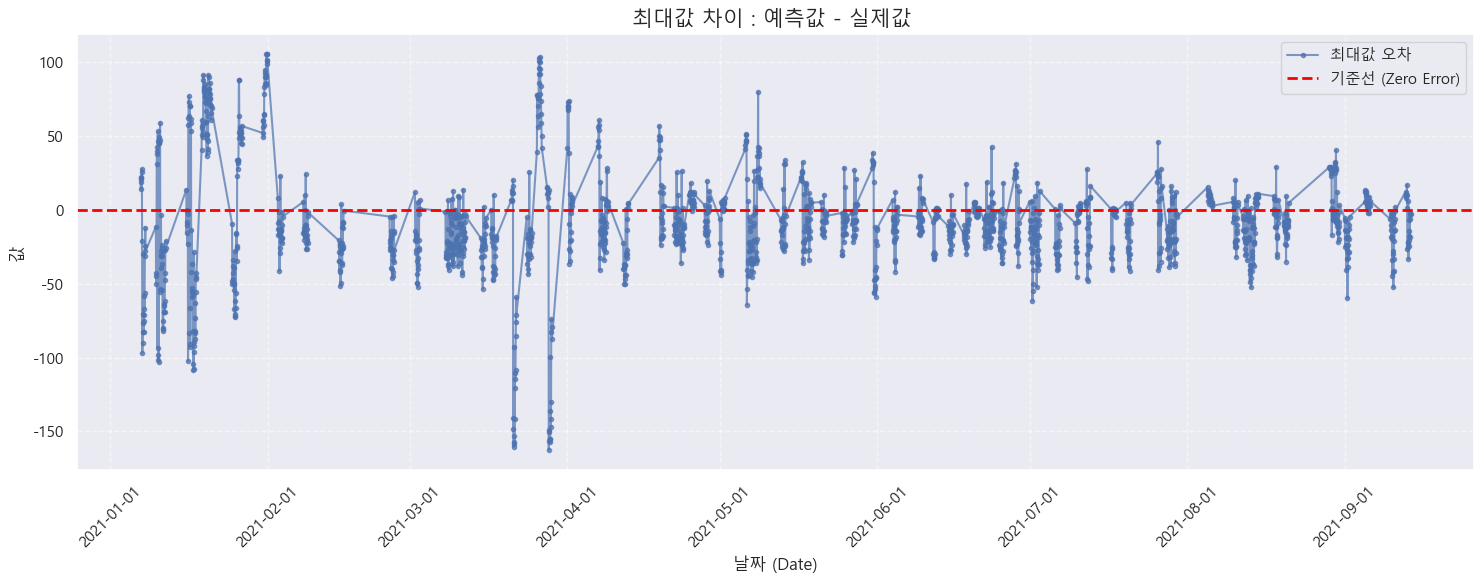

In [111]:
# 한글 깨짐 방지 (필요 시 설정)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(15, 6))

# 1. 인덱스를 날짜순으로 정렬
results_df = results_df.sort_index()

# 데이터 시각화
plt.plot(results_df.index, blind_df['최대_예측'] - blind_df['최대'], label='최대값 오차', marker='o', markersize=3, alpha=0.7)
# plt.plot(results_df.index, results_df['최대_예측'], label='예측 최대값', linestyle='--', alpha=0.8)

# --- y=0 기준 라인 추가 ---
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='기준선 (Zero Error)')
# -----------------------

# X축 날짜 간격 설정 (데이터가 많을 경우 대비)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # 자동으로 적절한 간격 선택
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # 날짜 형식 지정

plt.title('최대값 차이 : 예측값 - 실제값 ', fontsize=15)
plt.xlabel('날짜 (Date)', fontsize=12)
plt.ylabel('값', fontsize=12)
plt.xticks(rotation=45) # 날짜 겹침 방지
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

C:\Users\Cherrima\AppData\Local\Temp\ipykernel_13736\3774941083.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


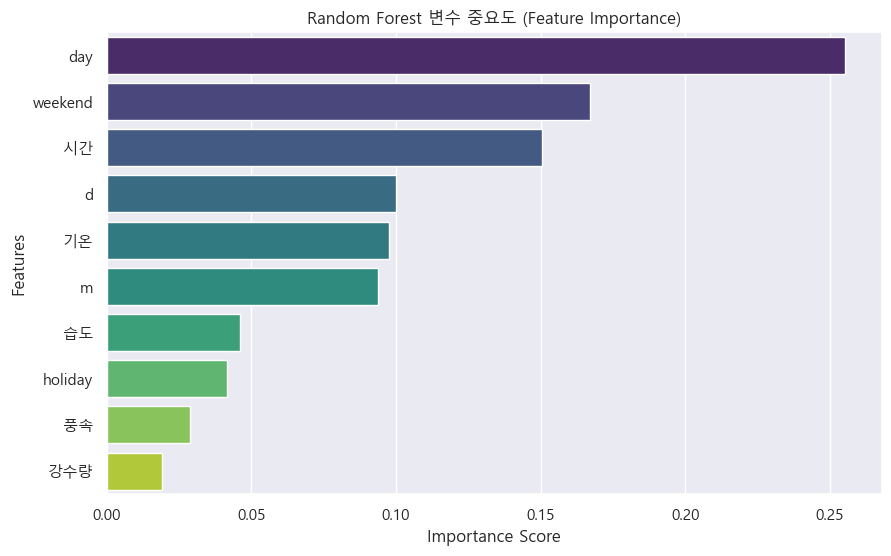

   Feature  Importance
5      day    0.255003
8  weekend    0.166980
0       시간    0.150466
6        d    0.100052
1       기온    0.097679
7        m    0.093717
3       습도    0.046110
9  holiday    0.041668
2       풍속    0.029009
4      강수량    0.019315


In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 중요도 추출 및 데이터프레임 변환
importances = blind_model.feature_importances_
feature_names = XB_train.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 2. 중요도 순으로 정렬
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# 3. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Random Forest 변수 중요도 (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# 4. 수치로 확인
print(feature_imp_df)